#Powered by [@CoinNoin](https://www.youtube.com/@CoinNoin)
[![Subscribe](https://img.shields.io/badge/YouTube-Subscribe%20@CoinNoin-red?style=for-the-badge&logo=youtube)](https://www.youtube.com/@CoinNoin)

In [1]:
#@title 1. Initialize Core Environment
#@markdown This prepares the ephemeral storage, installs ComfyUI, and configures the GGUF integration tools for Z-Image-Turbo.

import os
import subprocess
from IPython.display import clear_output

LOCAL_WORKSPACE = "/content/ComfyUI"

print("🚀 [@CoinNoin] Initializing Core Architecture...")
if not os.path.exists(LOCAL_WORKSPACE):
    !git clone --depth 1 https://github.com/comfyanonymous/ComfyUI {LOCAL_WORKSPACE} &> /dev/null
    print("   ✓ Core Engine Cloned")
else:
    !cd {LOCAL_WORKSPACE} && git pull &> /dev/null
    print("   ✓ Core Engine Updated")

print("📦 [@CoinNoin] Installing Dependencies (This takes a moment)...")
!cd {LOCAL_WORKSPACE} && pip install -q xformers!=0.0.18 -r requirements.txt --extra-index-url https://download.pytorch.org/whl/cu121 &> /dev/null

GGUF_NODE_DIR = os.path.join(LOCAL_WORKSPACE, "custom_nodes/ComfyUI-GGUF")
if not os.path.exists(GGUF_NODE_DIR):
    print("🧩 [@CoinNoin] Installing GGUF Processing Nodes...")
    !git clone https://github.com/city96/ComfyUI-GGUF {GGUF_NODE_DIR} &> /dev/null
    !pip install -q -r {GGUF_NODE_DIR}/requirements.txt &> /dev/null
else:
    !cd {GGUF_NODE_DIR} && git pull &> /dev/null

clear_output()
print("✅ [@CoinNoin] Environment Ready!")

✅ [@CoinNoin] Environment Ready!


In [2]:
#@title 2. High-Speed Asset Downloader & LoRA Setup
#@markdown The **Z-Image-Turbo Q8_0 GGUF** and required base assets are fetched automatically. You can optionally download or upload a LoRA file.

# --- Optional LoRA Source ---
LORA_SOURCE = "None (No LoRA)" #@param ["None (No LoRA)", "Download from URL", "Upload from Computer"]
LORA_URLS = "" #@param {type:"string"}

import os
import subprocess
import urllib.parse
from google.colab import files

WORKSPACE = "/content/ComfyUI"

# Fixed Models for Z-Image-Turbo Edit
FIXED_UNET_URL = "https://huggingface.co/unsloth/Z-Image-Turbo-GGUF/resolve/main/z-image-turbo-Q8_0.gguf"
TEXT_ENCODER_URLS = "https://huggingface.co/Comfy-Org/z_image_turbo/resolve/main/split_files/text_encoders/qwen_3_4b.safetensors"
VAE_URLS = "https://huggingface.co/Comfy-Org/z_image_turbo/resolve/main/split_files/vae/ae.safetensors"

DIRS = {
    "unet":  os.path.join(WORKSPACE, "models/unet"),
    "clip":  os.path.join(WORKSPACE, "models/clip"),
    "text_encoders": os.path.join(WORKSPACE, "models/text_encoders"),
    "vae":   os.path.join(WORKSPACE, "models/vae"),
    "loras": os.path.join(WORKSPACE, "models/loras"),
    "input": os.path.join(WORKSPACE, "input"),
}

for p in DIRS.values():
    os.makedirs(p, exist_ok=True)

print("⚡ [@CoinNoin] Configuring Aria2c Accelerator...")
subprocess.run(['apt-get', '-y', 'install', '-qq', 'aria2'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

def download_file(url, target_dir, filename=None):
    if not url.strip(): return
    if not filename:
        parsed_url = urllib.parse.urlparse(url)
        filename = os.path.basename(parsed_url.path)
    if os.path.exists(os.path.join(target_dir, filename)) and os.path.getsize(os.path.join(target_dir, filename)) > 1000000:
        print(f"   ✅ Already Cached: {filename}")
        return

    print(f"   📥 Fetching: {filename if filename else url[:40]}...")
    aria2_cmd = [
        "aria2c", "--console-log-level=error", "--summary-interval=10",
        "-c", "-x", "16", "-s", "16", "-k", "1M"
    ]
    if "civitai.com" in url or not filename:
        aria2_cmd.extend(["--content-disposition", url, "-d", target_dir])
    else:
        aria2_cmd.extend(["-o", filename, url, "-d", target_dir])

    subprocess.run(aria2_cmd, check=True)
    print(f"   ✅ Saved in {os.path.basename(target_dir)}")

# Download required base assets
download_file(FIXED_UNET_URL, DIRS["unet"])
download_file(TEXT_ENCODER_URLS, DIRS["clip"])
download_file(VAE_URLS, DIRS["vae"])

# Symlink text encoder for compatibility
clip_src = os.path.join(DIRS["clip"], "qwen_3_4b.safetensors")
clip_dst = os.path.join(DIRS["text_encoders"], "qwen_3_4b.safetensors")
if os.path.exists(clip_src) and not os.path.exists(clip_dst):
    os.symlink(clip_src, clip_dst)

# Handle optional LoRA
ACTIVE_LORA_FILENAME = ""

if LORA_SOURCE == "Download from URL":
    if LORA_URLS.strip():
        parsed_name = os.path.basename(urllib.parse.urlparse(LORA_URLS.strip()).path)
        if not parsed_name.endswith(('.safetensors', '.pt', '.ckpt')):
            parsed_name = "downloaded_lora.safetensors"
        download_file(LORA_URLS.strip(), DIRS["loras"], filename=parsed_name)
        ACTIVE_LORA_FILENAME = parsed_name
    else:
        print("⚠️ No LoRA URL provided. Proceeding without LoRA.")
elif LORA_SOURCE == "Upload from Computer":
    print("\n📤 [@CoinNoin] Select your LoRA (.safetensors) file to upload:")
    uploaded = files.upload()
    if uploaded:
        for fname in uploaded.keys():
            dest = os.path.join(DIRS["loras"], fname)
            os.replace(fname, dest)
            ACTIVE_LORA_FILENAME = fname
            print(f"   ✅ LoRA uploaded: {fname}")
    else:
        print("⚠️ No file uploaded. Proceeding without LoRA.")
else:
    print("ℹ️ Running in Pure Base Model Mode (No LoRA).")

# List all available LoRAs in the directory
available_loras = [f for f in os.listdir(DIRS["loras"]) if f.endswith(('.safetensors', '.pt', '.ckpt'))]
print("\n📂 [@CoinNoin] Available LoRAs in storage:")
if available_loras:
    for idx, lora_name in enumerate(available_loras, 1):
        print(f"   {idx}. {lora_name}")
        if idx == 1:
          recent_lora = lora_name
else:
    print("   (None found - model will run without LoRA)")

print("\n✅ [@CoinNoin] All core assets secured!")

⚡ [@CoinNoin] Configuring Aria2c Accelerator...
   📥 Fetching: z-image-turbo-Q8_0.gguf...
   ✅ Saved in unet
   📥 Fetching: qwen_3_4b.safetensors...
   ✅ Saved in clip
   📥 Fetching: ae.safetensors...
   ✅ Saved in vae
ℹ️ Running in Pure Base Model Mode (No LoRA).

📂 [@CoinNoin] Available LoRAs in storage:
   (None found - model will run without LoRA)

✅ [@CoinNoin] All core assets secured!


📤 [@CoinNoin] Please upload your SOURCE image to edit:


Saving grok.jpg to grok.jpg
   ✅ Source image saved!


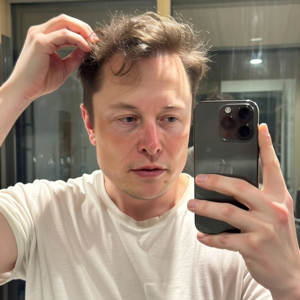


➜ [@CoinNoin] Edit Details | Max Dim: 1024 | Denoise: 0.75 | Seed: 679133253631070 | Steps: 9
📝 Prompt: 'Woman holding a brick.'
ℹ️ [@CoinNoin] Running generation without LoRA.

📥 Submitting workflow to API...
✨ Processing and Sampling (Check ComfyUI server logs if stuck)...
🖼️ Decoding Final Masterpiece...
✓ [@CoinNoin] Saved: @CoinNoin_ZEdit_00001_.png


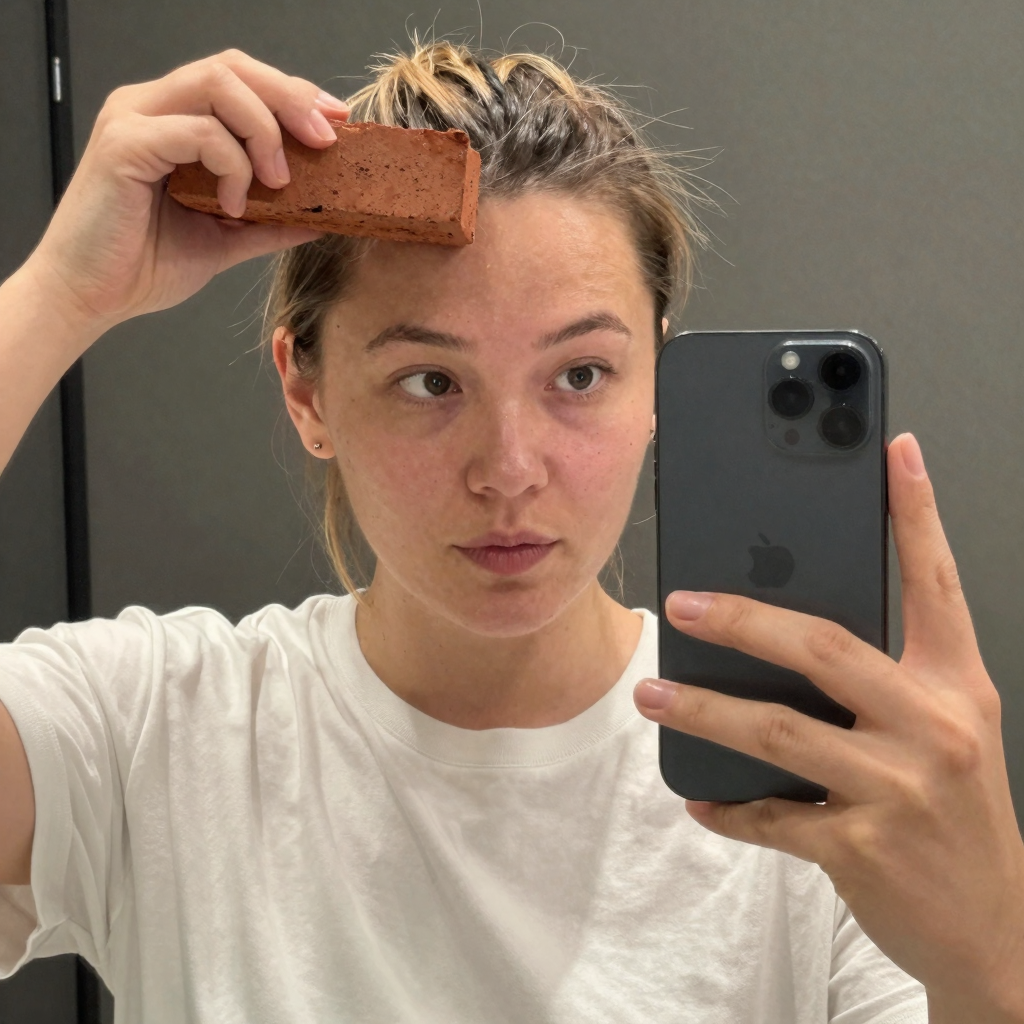


📥 [@CoinNoin] Download Started...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
#@title 3. Z-Image-Turbo Edit Generation
#@markdown Provide your edit prompt, upload your source image, and adjust editing sliders.

# --- Upload Controls ---
UPLOAD_SOURCE_IMAGE = True #@param {type:"boolean"}
#@markdown *If checked, Colab will prompt you to upload an image when you run this cell. Uncheck to use previously uploaded image.*

# --- Generation Settings ---
PROMPT = "Woman holding a brick." #@param {type:"string"}
NEGATIVE_PROMPT = "blurry, low quality, deformed, artifacts, bad anatomy" #@param {type:"string"}

MAX_DIMENSION = 1024 #@param {type:"slider", min:512, max:2048, step:64}
BATCH_SIZE = 1 #@param {type:"slider", min:1, max:4, step:1}
DENOISE = 0.75 #@param {type:"slider", min:0.0, max:1.0, step:0.05}

# --- LoRA Selection ---
#@markdown *Guide: Choose **None** to run without LoRA, **auto** to use the most recent LoRA, or type the exact filename.*
LORA_FILENAME = "None" #@param ["None", "auto"] {allow-input: true}
LORA_Trigger_Words = "" #@param {type:"string"}
LORA_STRENGTH = 1.0 #@param {type:"slider", min:0.0, max:2.0, step:0.05}

# --- Advanced Sampler Settings ---
STEPS = 9 #@param {type:"slider", min:1, max:20, step:1}
CFG = 1.0 #@param {type:"number"}
SAMPLER_NAME = "euler" #@param ["euler", "euler_ancestral", "heun", "dpm_2", "dpm_2_ancestral", "lms", "dpm_fast", "dpm_adaptive", "dpmpp_2s_ancestral", "dpmpp_sde", "dpmpp_sde_gpu", "dpmpp_2m", "dpmpp_2m_sde", "dpmpp_2m_sde_gpu", "dpmpp_3m_sde", "dpmpp_3m_sde_gpu", "ddpm", "lcm", "ddim", "uni_pc", "uni_pc_bh2", "res_multistep"] {allow-input: true}
SCHEDULER = "simple" #@param ["normal", "karras", "exponential", "sgm_uniform", "simple", "ddim_uniform", "beta"] {allow-input: true}
AURA_SHIFT = 3.0 #@param {type:"slider", min:1.0, max:10.0, step:0.5}
SEED = 0 #@param {type:"integer"}

# --- Direct Download (No ZIP) ---
AUTO_DOWNLOAD = True #@param {type:"boolean"}

import sys
import os
import json
import time
import random
import subprocess
import urllib.request
from google.colab import files
from PIL import Image
from IPython.display import display, Image as IPImage, clear_output

WORKSPACE = "/content/ComfyUI"
INPUT_DIR = os.path.join(WORKSPACE, "input")
os.chdir(WORKSPACE)

FINAL_PROMPT = PROMPT if LORA_FILENAME == "None" else LORA_Trigger_Words + ", " + PROMPT

# Auto-detect LoRA if set to 'auto'
if LORA_FILENAME.lower() == "auto":
    if 'ACTIVE_LORA_FILENAME' in globals() and ACTIVE_LORA_FILENAME:
      LORA_FILENAME = ACTIVE_LORA_FILENAME
    else:
        lora_dir = os.path.join(WORKSPACE, "models/loras")
        available = [f for f in os.listdir(lora_dir) if f.endswith(('.safetensors', '.pt', '.ckpt'))] if os.path.exists(lora_dir) else []
        LORA_FILENAME = available[0] if available else "None"
elif LORA_FILENAME.lower() == "none":
    LORA_FILENAME = "None"

if SEED == 0:
    SEED = random.randint(1, 1125899906842624)

print("🔌 [@CoinNoin] Checking ComfyUI Server Status...")
def start_server():
    req = urllib.request.Request("http://127.0.0.1:8188")
    try:
        urllib.request.urlopen(req)
        print("   🟢 Server is already running.")
    except:
        print("   🚀 Starting ComfyUI Server in background...")
        subprocess.Popen([sys.executable, "main.py"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        while True:
            try:
                urllib.request.urlopen(req)
                print("   🟢 Server is now up and ready!")
                break
            except:
                time.sleep(2)

start_server()
clear_output()

# Handle Uploads
input_image_filename = "source_input.png"
if UPLOAD_SOURCE_IMAGE:
    print("📤 [@CoinNoin] Please upload your SOURCE image to edit:")
    uploaded = files.upload()
    if uploaded:
        source_name = list(uploaded.keys())[0]
        os.replace(source_name, os.path.join(INPUT_DIR, input_image_filename))
        saved_path = os.path.join(INPUT_DIR, input_image_filename)
        print("   ✅ Source image saved!")

        img = Image.open(saved_path)
        display(img.resize((300, int(300 * img.height / img.width))))

    else:
        print("   ❌ No image uploaded. Will attempt to use cached image.")
else:
    print("   ℹ️ Using previously uploaded source image.")

if not os.path.exists(os.path.join(INPUT_DIR, input_image_filename)):
    raise RuntimeError("❌ No input image found in storage! Please check 'UPLOAD_SOURCE_IMAGE' and run again.")

# Brand visibility prefix in filename
BRAND_PREFIX = "@CoinNoin_ZEdit"

print(f"\n\033[94m➜ [@CoinNoin] Edit Details | Max Dim: {MAX_DIMENSION} | Denoise: {DENOISE} | Seed: {SEED} | Steps: {STEPS}\033[0m")
print(f"📝 Prompt: '{FINAL_PROMPT}'")

# Build Z-Image-Turbo Edit Architecture
workflow = {
    "39": {"inputs": {"clip_name": "qwen_3_4b.safetensors", "type": "lumina2", "device": "default"}, "class_type": "CLIPLoader"},
    "40": {"inputs": {"vae_name": "ae.safetensors"}, "class_type": "VAELoader"},
    "45": {"inputs": {"text": FINAL_PROMPT, "clip": ["39", 0]}, "class_type": "CLIPTextEncode"},
    "46": {"inputs": {"unet_name": "z-image-turbo-Q8_0.gguf"}, "class_type": "UnetLoaderGGUF"},
    "43": {"inputs": {"samples": ["44", 0], "vae": ["40", 0]}, "class_type": "VAEDecode"},
    "9":  {"inputs": {"filename_prefix": BRAND_PREFIX, "images": ["43", 0]}, "class_type": "SaveImage"},
    "58": {"inputs": {"image": input_image_filename}, "class_type": "LoadImage"},
    "65": {"inputs": {"image": ["58", 0], "upscale_method": "area", "largest_size": MAX_DIMENSION}, "class_type": "ImageScaleToMaxDimension"},
    "57": {"inputs": {"pixels": ["65", 0], "vae": ["40", 0]}, "class_type": "VAEEncode"},
    "66": {"inputs": {"samples": ["57", 0], "amount": BATCH_SIZE}, "class_type": "RepeatLatentBatch"}
}

# Apply Negative Prompt
if NEGATIVE_PROMPT.strip():
    workflow["42"] = {"inputs": {"text": NEGATIVE_PROMPT, "clip": ["39", 0]}, "class_type": "CLIPTextEncode"}
else:
    workflow["42"] = {"inputs": {"conditioning": ["45", 0]}, "class_type": "ConditioningZeroOut"}

# Attach LoRA only if specified and exists
model_output = ["46", 0]
if LORA_FILENAME.strip() and LORA_FILENAME.lower() != "none":
    lora_path = os.path.join(WORKSPACE, "models/loras", LORA_FILENAME)
    if os.path.exists(lora_path):
        workflow["48"] = {
            "inputs": {"lora_name": LORA_FILENAME, "strength_model": LORA_STRENGTH, "model": ["46", 0]},
            "class_type": "LoraLoaderModelOnly"
        }
        model_output = ["48", 0]
        print(f"✨ [@CoinNoin] LoRA Applied: {LORA_FILENAME} (Strength: {LORA_STRENGTH})")
    else:
        print(f"⚠️ LoRA '{LORA_FILENAME}' not found in models/loras. Running without LoRA.")
else:
    print("ℹ️ [@CoinNoin] Running generation without LoRA.")

workflow["47"] = {"inputs": {"shift": AURA_SHIFT, "model": model_output}, "class_type": "ModelSamplingAuraFlow"}

workflow["44"] = {
    "inputs": {
        "seed": SEED,
        "steps": STEPS,
        "cfg": CFG,
        "sampler_name": SAMPLER_NAME,
        "scheduler": SCHEDULER,
        "denoise": DENOISE,
        "model": ["47", 0],
        "positive": ["45", 0],
        "negative": ["42", 0],
        "latent_image": ["66", 0]
    },
    "class_type": "KSampler"
}

p = {"prompt": workflow}
data = json.dumps(p).encode('utf-8')
req = urllib.request.Request("http://127.0.0.1:8188/prompt", data=data)

print("\n📥 Submitting workflow to API...")
try:
    response = urllib.request.urlopen(req)
    prompt_id = json.loads(response.read())['prompt_id']
except Exception as e:
    print(f"❌ API Error: {e}")
    raise

print("✨ Processing and Sampling (Check ComfyUI server logs if stuck)...")
while True:
    try:
        history_req = urllib.request.Request(f"http://127.0.0.1:8188/history/{prompt_id}")
        history_res = urllib.request.urlopen(history_req)
        history_data = json.loads(history_res.read())
        if prompt_id in history_data:
            outputs = history_data[prompt_id]['outputs']
            break
    except:
        pass
    time.sleep(1)

print("🖼️ Decoding Final Masterpiece...")
generated_images = []
for node_id, node_output in outputs.items():
    if 'images' in node_output:
        for image in node_output['images']:
            filename = image['filename']
            img_path = os.path.join(WORKSPACE, "output", filename)
            generated_images.append(img_path)
            print(f"\033[92m✓ [@CoinNoin] Saved: {filename}\033[0m")
            display(IPImage(filename=img_path))

# Direct download trigger
if AUTO_DOWNLOAD and generated_images:
    print("\n📥 [@CoinNoin] Download Started...")
    for img_file in generated_images:
        files.download(img_file)